In [1]:
# PROJECT: CUSTOMER PERCEPTION TOWARDS RESTAURANTS IN NEPAL

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.sans-serif': 'Arial', 'font.family': 'sans-serif'})

In [ ]:
#Load Dataset

In [6]:
file_path = "C:/Users/admin/Downloads/Customer Survey.xlsx"

In [8]:
df = pd.read_excel(file_path)

In [9]:
df.columns = [col.strip() for col in df.columns]

In [ ]:
#COLUMN RENAMING & PREPROCESSING

In [10]:
col_mapping = {
    'Age group :': 'Age_Group',
    'Gender :': 'Gender',
    'Occupation :': 'Occupation',
    'Monthly Income': 'Monthly_Income',
    'How did you first learn about Korean restaurants?': 'Discovery_Source',
    'How often do you visit Korean restaurants?': 'Visit_Frequency',
    'What is the primary reason for choosing a Korean restaurant?': 'Primary_Reason',
    'How comfortable are you trying new Korean dishes?': 'Comfort_New_Dishes',
    'Which factor influences your restaurant choice the most?': 'Top_Influencing_Factor'
}

In [12]:
likert_cols = {
    df.columns[10]: 'Variety',
    df.columns[11]: 'Taste',
    df.columns[12]: 'Quality',
    df.columns[13]: 'Authenticity',
    df.columns[14]: 'Portion_Size',
    df.columns[15]: 'Affordability',
    df.columns[16]: 'Price_Fairness',
    df.columns[17]: 'Promotions',
    df.columns[18]: 'Staff_Courteous',
    df.columns[19]: 'Service_Prompt',
    df.columns[20]: 'Staff_Communication',
    df.columns[21]: 'Music_Ambiance',
    df.columns[22]: 'Decor',
    df.columns[23]: 'Cleanliness',
    df.columns[24]: 'KDrama_Influence',
    df.columns[25]: 'KPop_SocialMedia',
    df.columns[26]: 'Cultural_Motivation',
    df.columns[27]: 'Overall_Satisfaction',
    df.columns[28]: 'Revisit_Intention',
    df.columns[29]: 'Recommendation'
}

In [13]:
df = df.rename(columns={**col_mapping, **likert_cols})

In [14]:
#LIKERT TEXT TO NUMERIC CONVERSION (1 TO 5 SCALE

In [15]:
likert_map = {
    'Strongly Disagree': 1,
    'Disagree': 2,
    'Neutral': 3,
    'Agree': 4,
    'Strongly Agree': 5
}

In [16]:
for col in likert_cols.values():
    df[col] = df[col].map(likert_map)

In [17]:
#COMPUTE CONSTRUCT COMPOSITE SCORES

In [20]:
df['Food_Quality_Score'] = df[['Variety', 'Taste', 'Quality', 'Authenticity', 'Portion_Size']].mean(axis=1)
df['Pricing_Score'] = df[['Affordability', 'Price_Fairness', 'Promotions']].mean(axis=1)
df['Service_Quality_Score'] = df[['Staff_Courteous', 'Service_Prompt', 'Staff_Communication']].mean(axis=1)
df['Ambiance_Cleanliness_Score'] = df[['Music_Ambiance', 'Decor', 'Cleanliness']].mean(axis=1)
df['Pop_Culture_Influence_Score'] = df[['KDrama_Influence', 'KPop_SocialMedia', 'Cultural_Motivation']].mean(axis=1)
df['Customer_Loyalty_Score'] = df[['Overall_Satisfaction', 'Revisit_Intention', 'Recommendation']].mean(axis=1)

In [21]:
df['Age_Group'] = df['Age_Group'].astype(str).str.replace('â€“', '-').str.replace('–', '-')

In [22]:
df.to_excel("Cleaned_Numeric_Survey_Data.xlsx", index=False)
print("Numeric data exported successfully to 'Cleaned_Numeric_Survey_Data.xlsx'.")

Numeric data exported successfully to 'Cleaned_Numeric_Survey_Data.xlsx'.


In [23]:
#DESCRIPTIVE STATISTICS

In [24]:
constructs = ['Food_Quality_Score', 'Pricing_Score', 'Service_Quality_Score', 
              'Ambiance_Cleanliness_Score', 'Pop_Culture_Influence_Score', 'Customer_Loyalty_Score']

summary_stats = df[constructs].agg(['mean', 'std', 'min', 'max']).round(2).T
summary_stats.columns = ['Mean', 'Std_Dev', 'Min', 'Max']
print("\n=== CONSTRUCT SUMMARY STATISTICS (1-5 SCALE) ===")
print(summary_stats)


=== CONSTRUCT SUMMARY STATISTICS (1-5 SCALE) ===
                             Mean  Std_Dev  Min  Max
Food_Quality_Score           4.10     0.95  1.0  5.0
Pricing_Score                3.78     1.03  1.0  5.0
Service_Quality_Score        3.97     1.05  1.0  5.0
Ambiance_Cleanliness_Score   4.01     1.04  1.0  5.0
Pop_Culture_Influence_Score  3.96     1.05  1.0  5.0
Customer_Loyalty_Score       4.08     0.99  1.0  5.0


In [25]:
#GRAPH 1: CORE CONSTRUCT MEANS COMPARISON BAR PLOT

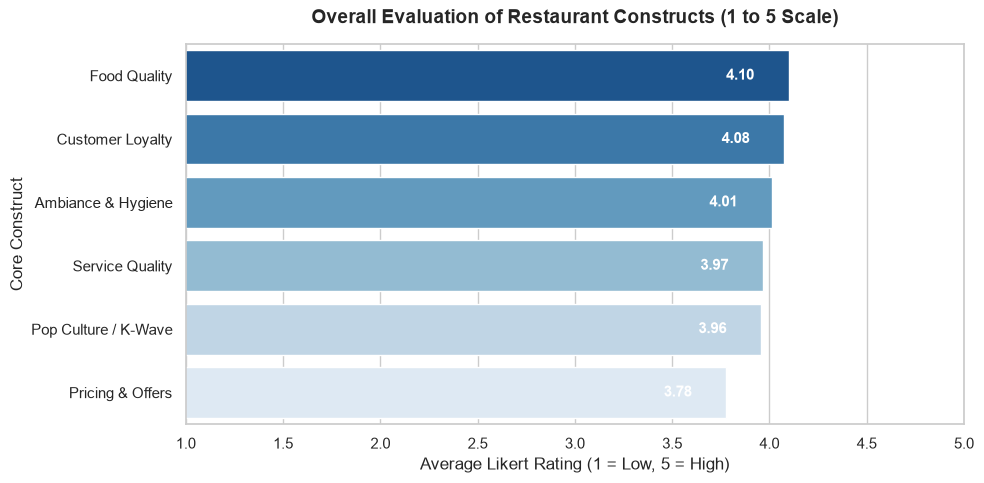

In [27]:
plt.figure(figsize=(10, 5))

construct_summary = pd.DataFrame({
    'Construct': ['Food Quality', 'Customer Loyalty', 'Service Quality', 
                  'Ambiance & Hygiene', 'Pricing & Offers', 'Pop Culture / K-Wave'],
    'Mean_Score': [
        df['Food_Quality_Score'].mean(),
        df['Customer_Loyalty_Score'].mean(),
        df['Service_Quality_Score'].mean(),
        df['Ambiance_Cleanliness_Score'].mean(),
        df['Pricing_Score'].mean(),
        df['Pop_Culture_Influence_Score'].mean()
    ]
}).sort_values(by='Mean_Score', ascending=False)

ax1 = sns.barplot(
    data=construct_summary, 
    x='Mean_Score', 
    y='Construct', 
    hue='Construct', 
    palette='Blues_r', 
    legend=False
)
plt.title('Overall Evaluation of Restaurant Constructs (1 to 5 Scale)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Average Likert Rating (1 = Low, 5 = High)', fontsize=12)
plt.ylabel('Core Construct', fontsize=12)
plt.xlim(1, 5)
for p in ax1.patches:
    width = p.get_width()
    ax1.annotate(f'{width:.2f}', 
                 (width - 0.25, p.get_y() + p.get_height() / 2.), 
                 ha='center', va='center', color='white', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('construct_means_comparison.png', dpi=300)
plt.show()

In [28]:
#GRAPH 2: DEMOGRAPHIC DISTRIBUTION (AGE & GENDER)

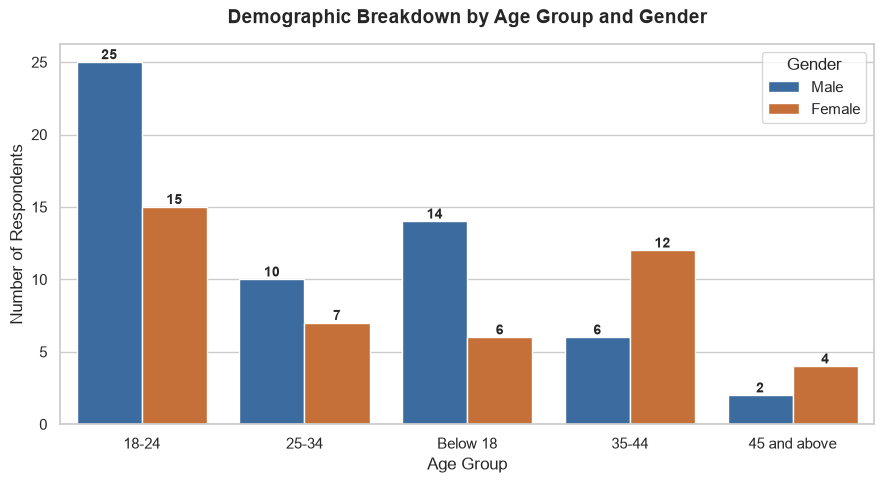

In [31]:
plt.figure(figsize=(9, 5))

# Using exactly 2 colors for the 2 gender categories in the dataset
ax2 = sns.countplot(data=df, x='Age_Group', hue='Gender', palette=['#2b6cb0', '#dd6b20'])
plt.title('Demographic Breakdown by Age Group and Gender', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Number of Respondents', fontsize=12)
plt.legend(title='Gender', loc='upper right')
for p in ax2.patches:
    height = p.get_height()
    if not np.isnan(height) and height > 0:
        ax2.annotate(f'{int(height)}', 
                     (p.get_x() + p.get_width() / 2., height), 
                     ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('demographics_distribution.png', dpi=300)
plt.show()

In [32]:
#GRAPH 3: POP CULTURE INFLUENCE VS CUSTOMER LOYALTY

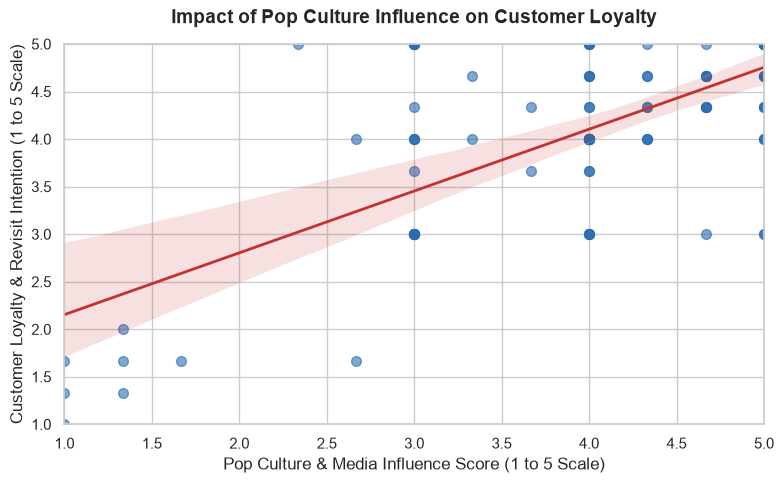

In [33]:
plt.figure(figsize=(8, 5))

sns.regplot(
    data=df, 
    x='Pop_Culture_Influence_Score', 
    y='Customer_Loyalty_Score',
    scatter_kws={'alpha': 0.6, 'color': '#2b6cb0', 's': 50},
    line_kws={'color': '#c53030', 'linewidth': 2}
)

plt.title('Impact of Pop Culture Influence on Customer Loyalty', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Pop Culture & Media Influence Score (1 to 5 Scale)', fontsize=12)
plt.ylabel('Customer Loyalty & Revisit Intention (1 to 5 Scale)', fontsize=12)
plt.xlim(1, 5)
plt.ylim(1, 5)

plt.tight_layout()
plt.savefig('culture_vs_loyalty_regression.png', dpi=300)
plt.show()